In [1]:
import time, joblib
import numpy as np
import pandas as pd
from src.preprocessing import load_and_clean, time_split, build_preprocessor, TARGET
from src.features import add_features, FEATURE_COLS

df = add_features(load_and_clean())
train, val, test = time_split(df)

X_train, y_train = train.drop(columns=["Date", TARGET]), train[TARGET]
X_val,   y_val   = val.drop(columns=["Date", TARGET]),   val[TARGET]

print("Train:", X_train.shape, " Heavy days:", y_train.sum())
print("Val:  ", X_val.shape,   " Heavy days:", y_val.sum())

Train: (98853, 28)  Heavy days: 319
Val:   (17231, 28)  Heavy days: 58


In [2]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print("Normal days per heavy-rain day:", round(spw))

Normal days per heavy-rain day: 309


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                           class_weight="balanced_subsample",
                                           n_jobs=-1, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                             scale_pos_weight=spw, eval_metric="aucpr",
                             n_jobs=-1, random_state=42),
}

In [4]:
from sklearn.pipeline import Pipeline

trained = {}
probs = {}

for name, model in models.items():
    start = time.time()
    pipe = Pipeline([
        ("prep",  build_preprocessor(FEATURE_COLS)),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    probs[name] = pipe.predict_proba(X_val)[:, 1]
    trained[name] = pipe
    joblib.dump(pipe, f"models/{name}.joblib")
    print(f"{name:20s} trained in {time.time() - start:.1f} sec")

LogisticRegression   trained in 3.9 sec
DecisionTree         trained in 2.8 sec
RandomForest         trained in 22.4 sec


c:\Users\kanis\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\kanis\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\kanis\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kanis\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036

KNN                  trained in 12.2 sec
XGBoost              trained in 9.2 sec


In [5]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score)

rows = []
for name, p in probs.items():
    pred = (p >= 0.5).astype(int)
    rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall":    recall_score(y_val, pred),
        "F1":        f1_score(y_val, pred),
        "ROC_AUC":   roc_auc_score(y_val, p),
        "PR_AUC":    average_precision_score(y_val, p),
    })

results = pd.DataFrame(rows).sort_values("PR_AUC", ascending=False).round(3)
results.to_csv("reports/model_comparison.csv", index=False)
results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LogisticRegression,0.913,0.034,0.914,0.066,0.967,0.274
2,RandomForest,0.996,0.360,0.155,0.217,0.962,0.212
3,KNN,0.997,0.000,0.000,0.000,0.824,0.176
4,XGBoost,0.990,0.150,0.448,0.225,0.945,0.157
1,DecisionTree,0.932,0.038,0.793,0.073,0.877,0.080


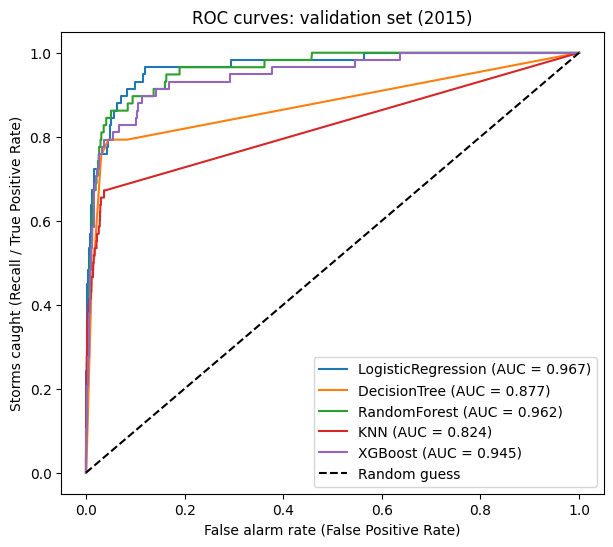

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_val, p)
    auc = roc_auc_score(y_val, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False alarm rate (False Positive Rate)")
plt.ylabel("Storms caught (Recall / True Positive Rate)")
plt.title("ROC curves: validation set (2015)")
plt.legend()
plt.savefig("reports/8_roc_curves.png", bbox_inches="tight")
plt.show()

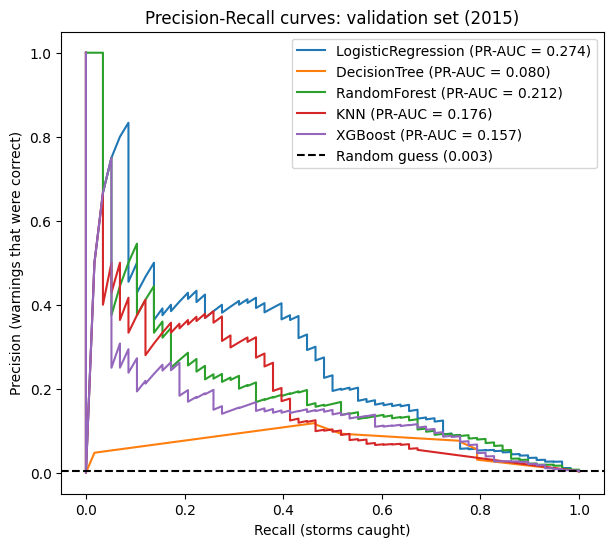

In [7]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7, 6))
for name, p in probs.items():
    prec, rec, _ = precision_recall_curve(y_val, p)
    ap = average_precision_score(y_val, p)
    plt.plot(rec, prec, label=f"{name} (PR-AUC = {ap:.3f})")

baseline = y_val.mean()
plt.axhline(baseline, color="k", linestyle="--", label=f"Random guess ({baseline:.3f})")
plt.xlabel("Recall (storms caught)")
plt.ylabel("Precision (warnings that were correct)")
plt.title("Precision-Recall curves: validation set (2015)")
plt.legend()
plt.savefig("reports/9_pr_curves.png", bbox_inches="tight")
plt.show()

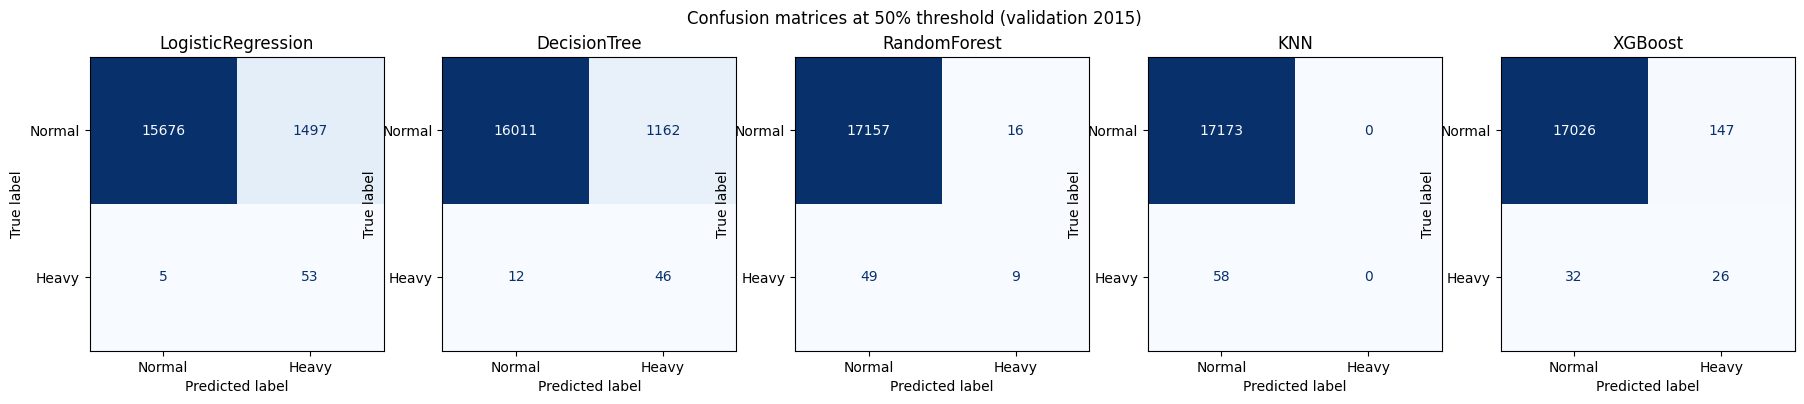

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, p) in zip(axes, probs.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_val, (p >= 0.5).astype(int), ax=ax, colorbar=False,
        display_labels=["Normal", "Heavy"], cmap="Blues")
    ax.set_title(name)
plt.suptitle("Confusion matrices at 50% threshold (validation 2015)")
plt.savefig("reports/10_confusion_matrices.png", bbox_inches="tight")
plt.show()

num__Humidity3pm       0.1204
num__TempRange         0.0718
num__HumidityChange    0.0687
num__MinTemp           0.0664
num__Rainfall          0.0607
num__Rain3dSum         0.0529
num__Humidity9am       0.0489
num__Cloud3pm          0.0422
num__Temp9am           0.0387
num__Sunshine          0.0318
cat__RainToday_Yes     0.0289
num__Pressure3pm       0.0282
num__WindGustSpeed     0.0238
num__Temp3pm           0.0237
num__MaxTemp           0.0235
dtype: float64


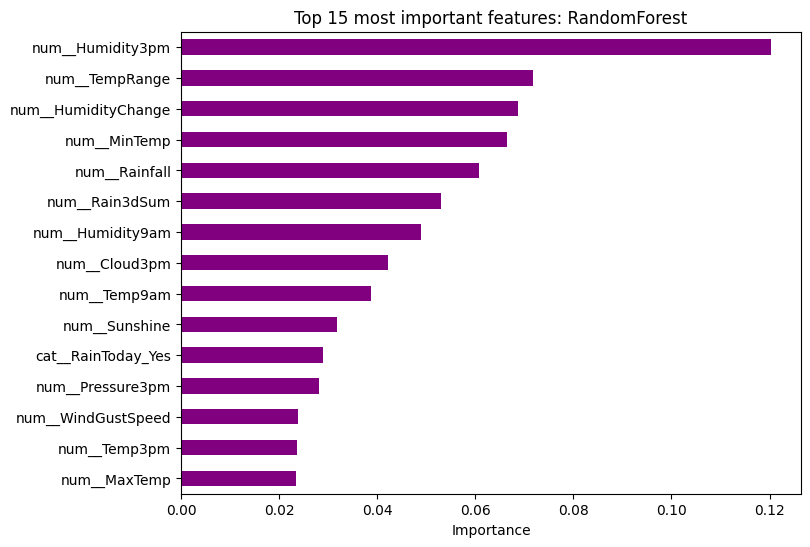

In [9]:
best_tree = results[results["Model"].isin(["XGBoost", "RandomForest"])].iloc[0]["Model"]
pipe = trained[best_tree]

names = pipe.named_steps["prep"].get_feature_names_out()
imp = pd.Series(pipe.named_steps["model"].feature_importances_, index=names)
top = imp.sort_values(ascending=False).head(15)
print(top.round(4))

top.sort_values().plot(kind="barh", figsize=(8, 6), color="purple")
plt.title(f"Top 15 most important features: {best_tree}")
plt.xlabel("Importance")
plt.savefig("reports/11_feature_importance.png", bbox_inches="tight")
plt.show()